# ⚖️ Fairness Evaluation & Bias Flagging
**Project:** Mitigating Algorithmic Bias in AI-Powered Resume Screening

Since the dataset does not contain explicit demographic labels, fairness is evaluated at the occupation-class level.

Three fairness flags:
1. **Uncertain Decision** — suitability score < 0.627 (empirical separation point)
2. **Potential Bias** — proxy tokens with high SHAP values
3. **Fairness Risk** — Disparate Impact < 0.80 (4/5 rule)

Fairness metrics (occupation-class level):
- **Cross-Occupation Selection Rate Parity** — mean suitability score equal across all occupation classes, ensuring no occupational group is systematically favored by the model
- **Per-Class Accuracy Parity** — TPR + FPR equal across occupation classes, where significant disparity indicates potential systematic bias in classification
- **Disparate Impact Ratio** — 4/5 rule (EEOC standard): ratio of selection rates between lowest and highest scoring occupation classes; below 0.8 indicates potential adverse impact


## 0. Imports & Config

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from sklearn.metrics import confusion_matrix

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams.update({"figure.dpi": 120})

# ── Paths ─────────────────────────────────────────────────────────────────────
BASE_DIR          = Path('/content/drive/MyDrive/CV-Screening')
SCORES_CSV        = BASE_DIR / 'suitability_scores.csv'
SHAP_PROXY_CSV    = BASE_DIR / 'shap_proxy_flags.csv'
FAIRNESS_CSV      = BASE_DIR / 'fairness_results.csv'
FLAGS_CSV         = BASE_DIR / 'flagged_resumes.csv'
PLOTS_DIR         = BASE_DIR / 'plots'
PLOTS_DIR.mkdir(exist_ok=True)

# ── Thresholds ────────────────────────────────────────────────────────────────
UNCERTAIN_THRESH  = 0.627   # empirical separation point (75th pct of false predictions)
PROXY_SHAP_THRESH = 0.005    # min mean_abs SHAP to flag proxy as bias
DI_THRESHOLD      = 0.80    # 4/5 rule (EEOC)

print("Config ready ✓")
print(f"  Uncertain threshold : {UNCERTAIN_THRESH}")
print(f"  SHAP proxy threshold: {PROXY_SHAP_THRESH}")
print(f"  DI threshold        : {DI_THRESHOLD}")


Config ready ✓
  Uncertain threshold : 0.627
  SHAP proxy threshold: 0.005
  DI threshold        : 0.8


## 1. Load & Aggregate Per-Resume

- Disini suitable == accuracy dari prediksi model nya

In [ ]:
from collections import Counter

scores_df = pd.read_csv(SCORES_CSV)
proxy_df  = pd.read_csv(SHAP_PROXY_CSV)

print(f"Scores loaded : {len(scores_df):,} chunks")
print(f"Proxy loaded  : {len(proxy_df):,} proxy token records")

# Aggregate chunks → per-resume (majority vote)
resume_df = (
    scores_df.groupby("filename")
    .apply(lambda g: pd.Series({
        "occupation":           g["occupation"].iloc[0],
        "predicted_occupation": Counter(g["predicted_occupation"]).most_common(1)[0][0],
        "suitability_score":    g["suitability_score"].mean(),
        "correct":              Counter(g["predicted_occupation"]).most_common(1)[0][0] == g["occupation"].iloc[0],
    }))
    .reset_index()
)

# Binary suitable = predicted == true label
resume_df["suitable"] = resume_df["correct"].astype(int)

print(f"\nTotal resumes     : {len(resume_df)}")
print(f"Overall suitable  : {resume_df['suitable'].mean():.4f}")
print(f"\nPer occupation:")
print(resume_df.groupby("occupation")[["suitable","suitability_score"]].agg(
    {"suitable":"mean","suitability_score":"mean"}
).round(3).to_string())


Scores loaded : 1,257 chunks
Proxy loaded  : 386 proxy token records

Total resumes     : 373
Overall suitable  : 0.7480

Per occupation:
                        suitable  suitability_score
occupation                                         
ACCOUNTANT                 0.833              0.670
ADVOCATE                   0.611              0.577
AGRICULTURE                0.333              0.614
APPAREL                    0.571              0.652
ARTS                       0.400              0.538
AUTOMOBILE                 0.600              0.645
AVIATION                   0.778              0.731
BANKING                    0.722              0.656
BPO                        0.333              0.575
BUSINESS-DEVELOPMENT       0.833              0.626
CHEF                       0.778              0.773
CONSTRUCTION               0.882              0.719
CONSULTANT                 0.588              0.561
DESIGNER                   0.750              0.786
DIGITAL-MEDIA              0.5

## 2. Fairness Metrics

In [ ]:
occ_metrics = []
overall_selection_rate = resume_df["suitable"].mean()

for occ in sorted(resume_df["occupation"].unique()):
    occ_df    = resume_df[resume_df["occupation"] == occ]
    other_df  = resume_df[resume_df["occupation"] != occ]

    n              = len(occ_df)
    selection_rate = occ_df["suitable"].mean()
    majority_rate  = other_df["suitable"].mean()
    di_ratio       = selection_rate / majority_rate if majority_rate > 0 else 0
    dp_diff        = selection_rate - overall_selection_rate

    # Per-Class Accuracy Parity
    y_true = (resume_df["occupation"] == occ).astype(int)
    y_pred = (resume_df["predicted_occupation"] == occ).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()
    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0

    occ_metrics.append({
        "occupation":     occ,
        "n_resumes":      n,
        "selection_rate": round(selection_rate, 4),
        "di_ratio":       round(di_ratio, 4),
        "dp_diff":        round(dp_diff, 4),
        "tpr":            round(tpr, 4),
        "fpr":            round(fpr, 4),
    })

metrics_df = pd.DataFrame(occ_metrics)
metrics_df.to_csv(FAIRNESS_CSV, index=False)

print(f"Saved: {FAIRNESS_CSV}")
print(f"\nFairness Metrics per Occupation:")
print(metrics_df[["occupation","selection_rate","di_ratio","dp_diff","tpr","fpr"]].to_string(index=False))


Saved: /content/drive/MyDrive/CV-Screening/fairness_results.csv

Fairness Metrics per Occupation:
            occupation  selection_rate  di_ratio  dp_diff    tpr    fpr
            ACCOUNTANT          0.8333    1.1206   0.0853 0.8333 0.0113
              ADVOCATE          0.6111    0.8095  -0.1369 0.6111 0.0169
           AGRICULTURE          0.3333    0.4396  -0.4147 0.3333 0.0082
               APPAREL          0.5714    0.7570  -0.1766 0.5714 0.0056
                  ARTS          0.4000    0.5245  -0.3480 0.4000 0.0028
            AUTOMOBILE          0.6000    0.8000  -0.1480 0.6000 0.0190
              AVIATION          0.7778    1.0419   0.0298 0.7778 0.0085
               BANKING          0.7222    0.9639  -0.0258 0.7222 0.0169
                   BPO          0.3333    0.4436  -0.4147 0.3333 0.0054
  BUSINESS-DEVELOPMENT          0.8333    1.1206   0.0853 0.8333 0.0310
                  CHEF          0.7778    1.0419   0.0298 0.7778 0.0085
          CONSTRUCTION          0.8824

In [ ]:
# Cross-Occupation Selection Rate Parity
dp_std = metrics_df["selection_rate"].std()
print("=== Cross-Occupation Selection Rate Parity ===")
print(f"Std dev across all occupation groups: {dp_std:.4f}")
print(f"{'PASS ✓' if dp_std < 0.10 else 'FAIL ✗ — high variance, selection rate parity not met'}")

print(f"\nSelection rate per occupation:")
print(metrics_df[["occupation","selection_rate","dp_diff"]].sort_values("selection_rate", ascending=False).to_string(index=False))


=== Cross-Occupation Selection Rate Parity ===
Std dev across all occupation groups: 0.1845
FAIL ✗ — high variance, selection rate parity not met

Selection rate per occupation:
            occupation  selection_rate  dp_diff
               TEACHER          1.0000   0.2520
                 SALES          0.8889   0.1409
           ENGINEERING          0.8889   0.1409
               FINANCE          0.8889   0.1409
          CONSTRUCTION          0.8824   0.1344
      PUBLIC-RELATIONS          0.8750   0.1270
            ACCOUNTANT          0.8333   0.0853
  BUSINESS-DEVELOPMENT          0.8333   0.0853
INFORMATION-TECHNOLOGY          0.8333   0.0853
            HEALTHCARE          0.8333   0.0853
                    HR          0.8125   0.0645
                  CHEF          0.7778   0.0298
              AVIATION          0.7778   0.0298
              DESIGNER          0.7500   0.0020
               BANKING          0.7222  -0.0258
              ADVOCATE          0.6111  -0.1369
      

## 3. Flag 1 — Uncertain Decision

In [ ]:
# Score < 0.627 → model confidence below empirical separation point
uncertain_df = resume_df[resume_df["suitability_score"] < UNCERTAIN_THRESH].copy()
uncertain_df["flag"] = "UNCERTAIN_DECISION"

print(f"Uncertain Decision flags : {len(uncertain_df)} resumes")
print(f"Threshold                : score < {UNCERTAIN_THRESH}")
print(f"({len(uncertain_df)/len(resume_df)*100:.1f}% of all resumes)")
print(f"\nPer occupation:")
print(uncertain_df["occupation"].value_counts().to_string())


Uncertain Decision flags : 165 resumes
Threshold                : score < 0.627
(44.2% of all resumes)

Per occupation:
occupation
ADVOCATE                  13
CONSULTANT                12
HEALTHCARE                11
ARTS                      10
BUSINESS-DEVELOPMENT      10
SALES                     10
FINANCE                    8
INFORMATION-TECHNOLOGY     8
HR                         8
BANKING                    7
ENGINEERING                7
CONSTRUCTION               7
FITNESS                    6
ACCOUNTANT                 6
AGRICULTURE                6
AVIATION                   6
CHEF                       5
DIGITAL-MEDIA              5
PUBLIC-RELATIONS           5
DESIGNER                   4
APPAREL                    4
TEACHER                    3
AUTOMOBILE                 2
BPO                        2


## 4. Flag 2 — Potential Bias

In [ ]:
# Tambahkan ini untuk lihat distribusi mean_abs semua proxy tokens
print(proxy_df.sort_values("mean_abs", ascending=False).to_string())

                 occupation        token  is_proxy      mean_abs          mean
0                CONSULTANT       female      True  1.453460e-02  1.453460e-02
1                CONSULTANT  experienced      True  1.425327e-02  1.425327e-02
2                   TEACHER  experienced      True  1.206908e-02  1.206908e-02
3               ENGINEERING       senior      True  9.924804e-03  9.864060e-03
4                ACCOUNTANT  experienced      True  9.632026e-03  9.632026e-03
5                  DESIGNER       senior      True  7.837416e-03  7.830131e-03
6                HEALTHCARE  experienced      True  7.038813e-03  7.038813e-03
7               ENGINEERING   experience      True  6.337455e-03  6.232507e-03
8              CONSTRUCTION       senior      True  6.146799e-03  6.146799e-03
9                  DESIGNER   experience      True  5.911152e-03  5.911152e-03
10         PUBLIC-RELATIONS  experienced      True  5.897496e-03  5.897496e-03
11   INFORMATION-TECHNOLOGY   experience      True  

In [ ]:
# Occupations where proxy tokens have high SHAP influence
high_proxy  = proxy_df[proxy_df["mean_abs"] >= PROXY_SHAP_THRESH]
biased_occs = set(high_proxy["occupation"].unique())

bias_df = resume_df[resume_df["occupation"].isin(biased_occs)].copy()
bias_df["flag"] = "POTENTIAL_BIAS"
bias_df["proxy_tokens"] = bias_df["occupation"].map(
    high_proxy.groupby("occupation")["token"].apply(list).to_dict()
)

print(f"Potential Bias flags : {len(bias_df)} resumes across {len(biased_occs)} occupations")
print(f"SHAP threshold       : mean_abs >= {PROXY_SHAP_THRESH}")
print(f"\nAffected occupations + proxy tokens:")
for occ in sorted(biased_occs):
    tokens = high_proxy[high_proxy["occupation"] == occ][["token","mean_abs"]] \
             .sort_values("mean_abs", ascending=False).head(5)
    print(f"  {occ}")
    for _, row in tokens.iterrows():
        print(f"      {row['token']:<20} SHAP={row['mean_abs']:.4f}")


Potential Bias flags : 153 resumes across 9 occupations
SHAP threshold       : mean_abs >= 0.005

Affected occupations + proxy tokens:
  ACCOUNTANT
      experienced          SHAP=0.0096
  CONSTRUCTION
      senior               SHAP=0.0061
  CONSULTANT
      female               SHAP=0.0145
      experienced          SHAP=0.0143
  DESIGNER
      senior               SHAP=0.0078
      experience           SHAP=0.0059
      boys                 SHAP=0.0051
  ENGINEERING
      senior               SHAP=0.0099
      experience           SHAP=0.0063
  HEALTHCARE
      experienced          SHAP=0.0070
  INFORMATION-TECHNOLOGY
      experience           SHAP=0.0053
  PUBLIC-RELATIONS
      experienced          SHAP=0.0059
  TEACHER
      experienced          SHAP=0.0121


## 5. Flag 3 — Fairness Risk (4/5 Rule)

In [ ]:
# Disparate Impact < 0.80 → Fairness Risk
at_risk = metrics_df[metrics_df["di_ratio"] < DI_THRESHOLD]
fairness_risk_occs = at_risk["occupation"].tolist()

risk_df = resume_df[resume_df["occupation"].isin(fairness_risk_occs)].copy()
risk_df["flag"] = "FAIRNESS_RISK"
risk_df = risk_df.merge(
    metrics_df[["occupation","di_ratio","selection_rate","tpr","fpr"]],
    on="occupation", how="left"
)

print(f"Fairness Risk flags : {len(risk_df)} resumes across {len(fairness_risk_occs)} occupations")
print(f"DI threshold        : < {DI_THRESHOLD} (4/5 rule)")
print(f"\nFlagged occupations:")
print(at_risk[["occupation","selection_rate","di_ratio","tpr","fpr"]].sort_values("di_ratio").to_string(index=False))


Fairness Risk flags : 72 resumes across 6 occupations
DI threshold        : < 0.8 (4/5 rule)

Flagged occupations:
   occupation  selection_rate  di_ratio    tpr    fpr
  AGRICULTURE          0.3333    0.4396 0.3333 0.0082
          BPO          0.3333    0.4436 0.3333 0.0054
         ARTS          0.4000    0.5245 0.4000 0.0028
      APPAREL          0.5714    0.7570 0.5714 0.0056
DIGITAL-MEDIA          0.5714    0.7570 0.5714 0.0167
   CONSULTANT          0.5882    0.7785 0.5882 0.0197


## 6. Combine All Flags

In [ ]:
all_flags = []

for _, row in resume_df.iterrows():
    flags = []
    score = row["suitability_score"]
    occ   = row["occupation"]

    if score < UNCERTAIN_THRESH:
        flags.append("UNCERTAIN_DECISION")
    if occ in biased_occs:
        flags.append("POTENTIAL_BIAS")
    if occ in fairness_risk_occs:
        flags.append("FAIRNESS_RISK")

    all_flags.append({
        "filename":             row["filename"],
        "occupation":           occ,
        "predicted_occupation": row["predicted_occupation"],
        "suitability_score":    score,
        "correct":              row["correct"],
        "flags":                ", ".join(flags) if flags else "NONE",
        "n_flags":              len(flags),
        "uncertain_decision":   "UNCERTAIN_DECISION" in flags,
        "potential_bias":       "POTENTIAL_BIAS" in flags,
        "fairness_risk":        "FAIRNESS_RISK" in flags,
    })

flags_df = pd.DataFrame(all_flags)
flags_df.to_csv(FLAGS_CSV, index=False)

print(f"Saved: {FLAGS_CSV}")
print(f"\nFlag summary:")
print(f"  UNCERTAIN_DECISION : {flags_df['uncertain_decision'].sum():>4} resumes")
print(f"  POTENTIAL_BIAS     : {flags_df['potential_bias'].sum():>4} resumes")
print(f"  FAIRNESS_RISK      : {flags_df['fairness_risk'].sum():>4} resumes")
print(f"  Any flag           : {(flags_df['n_flags'] > 0).sum():>4} resumes")
print(f"  No flag (clean)    : {(flags_df['n_flags'] == 0).sum():>4} resumes")
print(f"\nMultiple flags (most at-risk resumes):")
print(flags_df[flags_df["n_flags"] > 1][[
        "filename","occupation","suitability_score","flags"
    ]].head(10).to_string(index=False))


Saved: /content/drive/MyDrive/CV-Screening/flagged_resumes.csv

Flag summary:
  UNCERTAIN_DECISION :  165 resumes
  POTENTIAL_BIAS     :  153 resumes
  FAIRNESS_RISK      :   72 resumes
  Any flag           :  283 resumes
  No flag (clean)    :   90 resumes

Multiple flags (most at-risk resumes):
    filename             occupation  suitability_score                                             flags
10041713.txt           CONSTRUCTION           0.598025                UNCERTAIN_DECISION, POTENTIAL_BIAS
10089434.txt INFORMATION-TECHNOLOGY           0.583640                UNCERTAIN_DECISION, POTENTIAL_BIAS
10332998.txt             CONSULTANT           0.502500 UNCERTAIN_DECISION, POTENTIAL_BIAS, FAIRNESS_RISK
10515955.txt          DIGITAL-MEDIA           0.380633                 UNCERTAIN_DECISION, FAIRNESS_RISK
10953078.txt            AGRICULTURE           0.430033                 UNCERTAIN_DECISION, FAIRNESS_RISK
11415967.txt             CONSULTANT           0.614267 UNCERTAIN_DECISIO

## 7. Visualisation

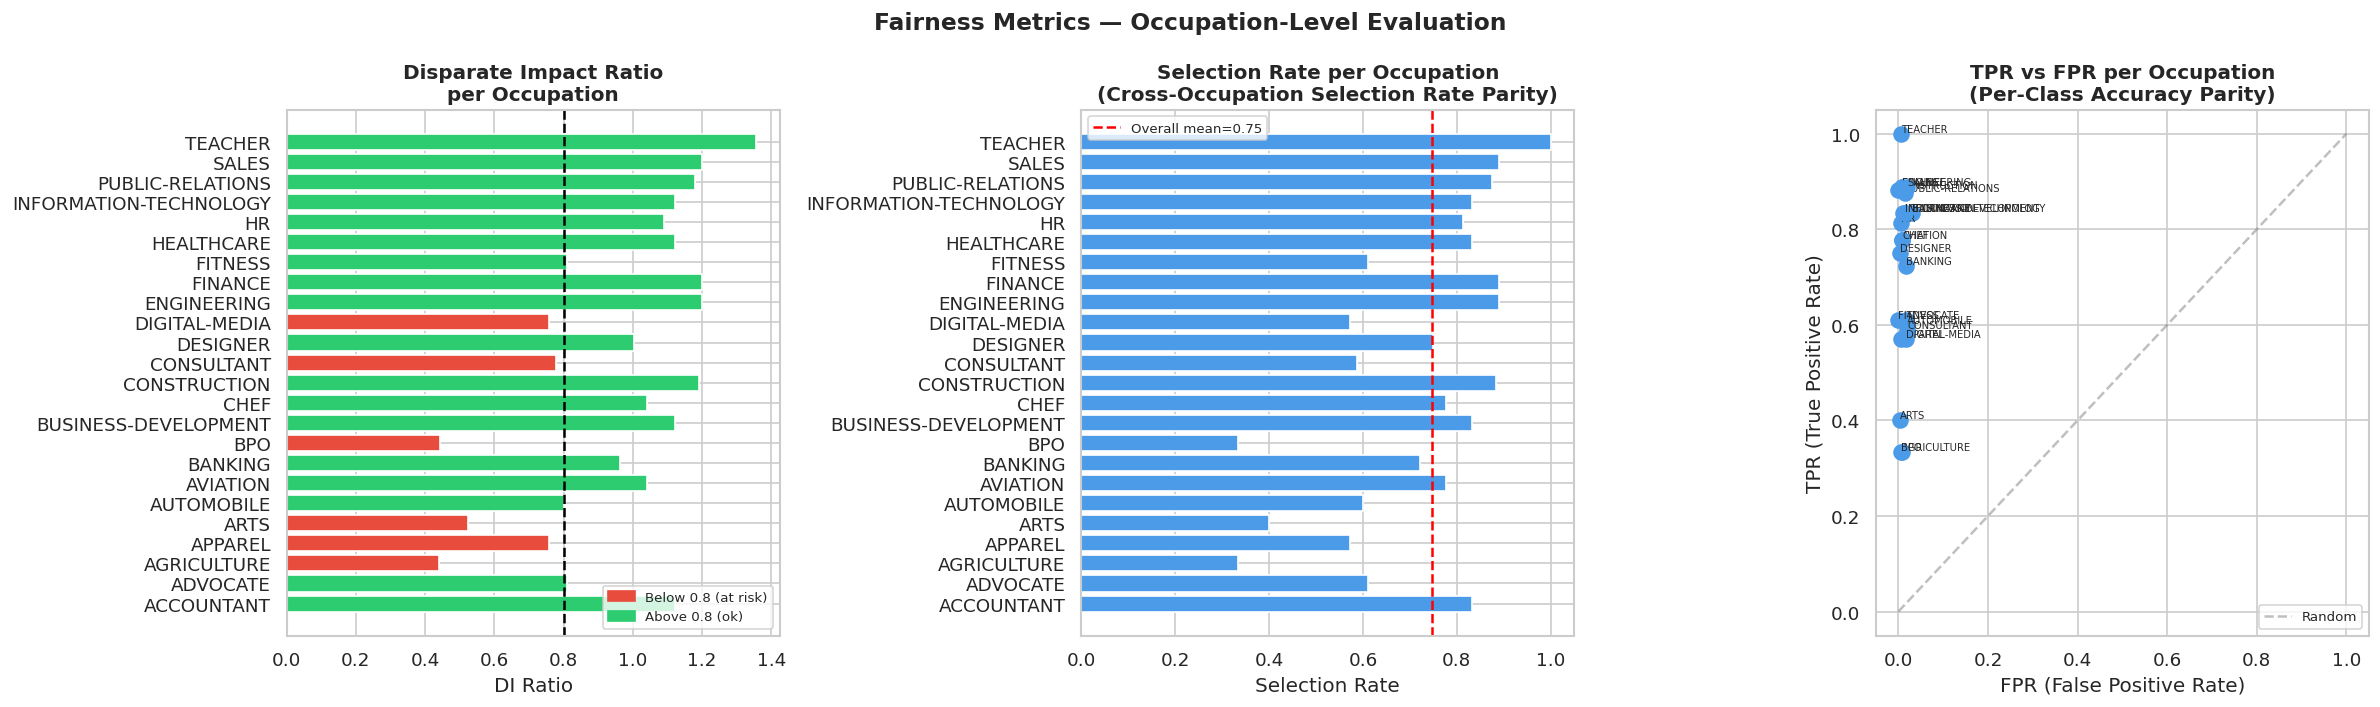

Saved: fairness_metrics.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# ── Plot 1: Disparate Impact per occupation ───────────────────────────────────
colors = ["#e74c3c" if d < DI_THRESHOLD else "#2ecc71"
          for d in metrics_df["di_ratio"]]
axes[0].barh(metrics_df["occupation"], metrics_df["di_ratio"], color=colors)
axes[0].axvline(DI_THRESHOLD, color="black", linestyle="--",
                label=f"4/5 rule ({DI_THRESHOLD})")
axes[0].set_title("Disparate Impact Ratio\nper Occupation", fontweight="bold")
axes[0].set_xlabel("DI Ratio")
axes[0].legend(fontsize=8)
red_patch   = mpatches.Patch(color="#e74c3c", label=f"Below {DI_THRESHOLD} (at risk)")
green_patch = mpatches.Patch(color="#2ecc71", label=f"Above {DI_THRESHOLD} (ok)")
axes[0].legend(handles=[red_patch, green_patch], fontsize=8)

# ── Plot 2: Selection Rate per Occupation ──────────────────────────────────────
occ_color = "#4C9BE8"
for _, row in metrics_df.iterrows():
    axes[1].barh(row["occupation"], row["selection_rate"],
                 color=occ_color)
axes[1].axvline(overall_selection_rate, color="red", linestyle="--",
                label=f"Overall mean={overall_selection_rate:.2f}")
axes[1].set_title("Selection Rate per Occupation\n(Cross-Occupation Selection Rate Parity)", fontweight="bold")
axes[1].set_xlabel("Selection Rate")
axes[1].legend(fontsize=8)

# ── Plot 3: TPR vs FPR (Equalized Odds) ──────────────────────────────────────
for _, row in metrics_df.iterrows():
    axes[2].scatter(row["fpr"], row["tpr"],
                    color=occ_color,
                    s=80, zorder=3)
    axes[2].annotate(row["occupation"], (row["fpr"], row["tpr"]),
                     fontsize=6, ha="left", va="bottom")
axes[2].plot([0,1],[0,1], color="gray", linestyle="--", alpha=0.5, label="Random")
axes[2].set_title("TPR vs FPR per Occupation\n(Per-Class Accuracy Parity)", fontweight="bold")
axes[2].set_xlabel("FPR (False Positive Rate)")
axes[2].set_ylabel("TPR (True Positive Rate)")
axes[2].legend(fontsize=8)

plt.suptitle("Fairness Metrics — Occupation-Level Evaluation",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(BASE_DIR / "fairness_metrics.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: fairness_metrics.png")


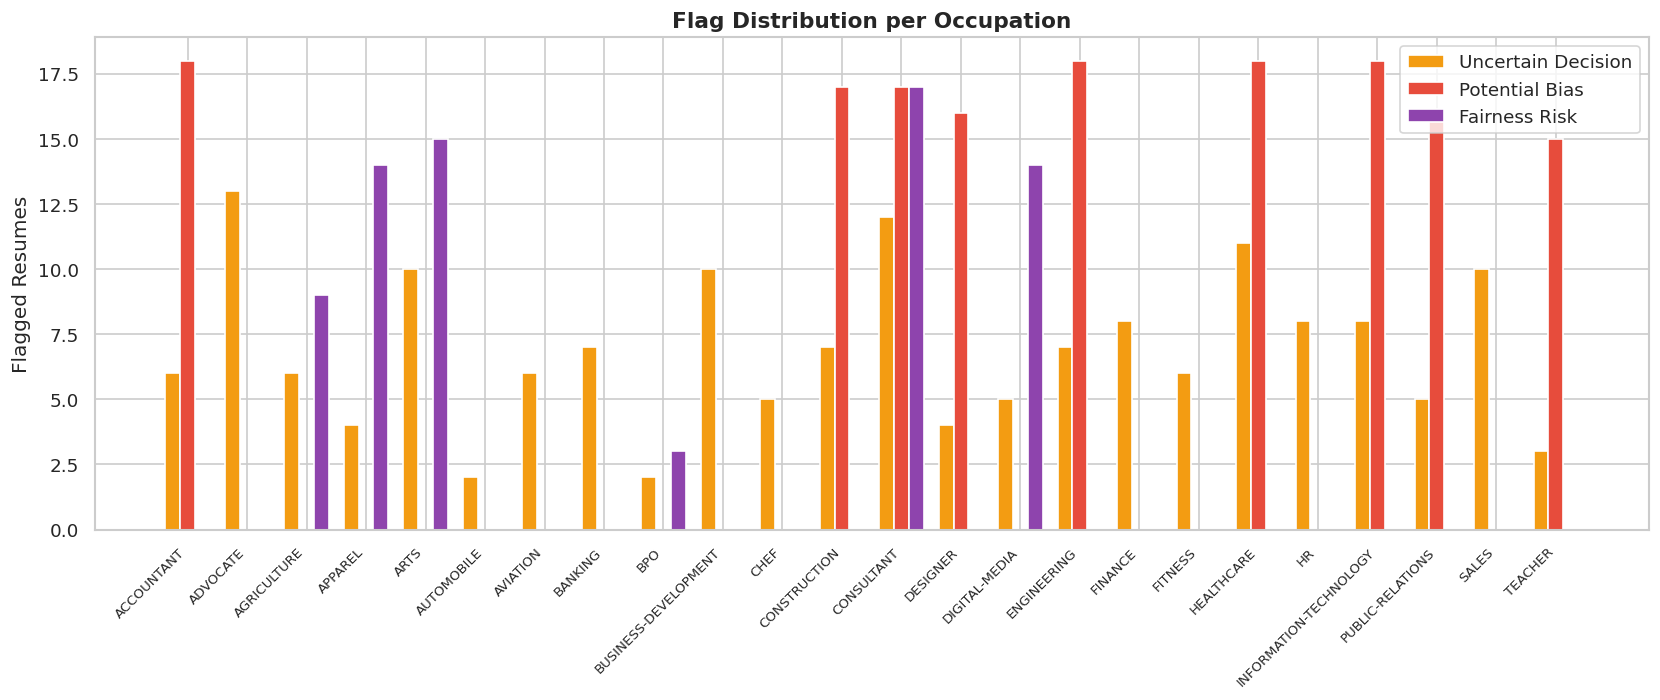

Saved: flag_distribution.png


In [ ]:
# Flag distribution per occupation
flag_counts = flags_df.groupby("occupation")[[
    "uncertain_decision","potential_bias","fairness_risk"
]].sum().reset_index()

fig, ax = plt.subplots(figsize=(14, 6))
x     = range(len(flag_counts))
width = 0.25

ax.bar([i - width for i in x], flag_counts["uncertain_decision"],
       width=width, label="Uncertain Decision", color="#f39c12")
ax.bar([i         for i in x], flag_counts["potential_bias"],
       width=width, label="Potential Bias",     color="#e74c3c")
ax.bar([i + width for i in x], flag_counts["fairness_risk"],
       width=width, label="Fairness Risk",      color="#8e44ad")

ax.set_xticks(list(x))
ax.set_xticklabels(flag_counts["occupation"], rotation=45, ha="right", fontsize=8)
ax.set_title("Flag Distribution per Occupation", fontsize=13, fontweight="bold")
ax.set_ylabel("Flagged Resumes")
ax.legend()
plt.tight_layout()
plt.savefig(BASE_DIR / "flag_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: flag_distribution.png")


## 8. Summary

In [ ]:
n_di_fail = (metrics_df["di_ratio"] < DI_THRESHOLD).sum()
dp_std    = metrics_df["selection_rate"].std()

print("=" * 60)
print("  FAIRNESS EVALUATION SUMMARY")
print("=" * 60)
print(f"  Total resumes          : {len(resume_df)}")
print(f"  Overall selection rate : {resume_df['suitable'].mean():.4f}")
print()
print(f"  Cross-Occupation Selection Rate Parity:")
print(f"    Std dev              : {dp_std:.4f}")
print(f"    {'PASS ✓' if dp_std < 0.10 else 'FAIL ✗ — parity not met'}")
print()
print(f"  Disparate Impact (4/5 rule):")
print(f"    Groups below 0.80    : {n_di_fail}/{len(metrics_df)}")
print(f"    {'PASS ✓' if n_di_fail == 0 else f'FAIL ✗ — {n_di_fail} groups at risk'}")
print()
print(f"  Flags:")
print(f"    UNCERTAIN_DECISION   : {flags_df['uncertain_decision'].sum()}")
print(f"    POTENTIAL_BIAS       : {flags_df['potential_bias'].sum()}")
print(f"    FAIRNESS_RISK        : {flags_df['fairness_risk'].sum()}")
print(f"    Total flagged        : {(flags_df['n_flags'] > 0).sum()}")
print("=" * 60)
print()
print("Output files:")
print(f"  fairness_results.csv  → metrics per occupation")
print(f"  flagged_resumes.csv   → all flags per resume → input to LLaMA")
print(f"  fairness_metrics.png")
print(f"  flag_distribution.png")
print()
print("Next: alpaca_llama.ipynb ← load flagged_resumes.csv + shap_proxy_flags.csv")

  FAIRNESS EVALUATION SUMMARY
  Total resumes          : 373
  Overall selection rate : 0.7480

  Cross-Occupation Selection Rate Parity:
    Std dev              : 0.1845
    FAIL ✗ — parity not met

  Disparate Impact (4/5 rule):
    Groups below 0.80    : 6/24
    FAIL ✗ — 6 groups at risk

  Flags:
    UNCERTAIN_DECISION   : 165
    POTENTIAL_BIAS       : 153
    FAIRNESS_RISK        : 72
    Total flagged        : 283

Output files:
  fairness_results.csv  → metrics per occupation
  flagged_resumes.csv   → all flags per resume → input to LLaMA
  fairness_metrics.png
  flag_distribution.png

Next: alpaca_llama.ipynb ← load flagged_resumes.csv + shap_proxy_flags.csv
